In [23]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

# Models
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


In [24]:
df = pd.read_csv("/content/customer_churn.csv")
df.head()


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [25]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


In [26]:
df.describe()


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


In [27]:
df.dtypes


,0
CustomerID,object
Tenure,int64
MonthlyCharges,int64
TotalCharges,int64
Contract,object
PaymentMethod,object
PaperlessBilling,object
SeniorCitizen,int64
Churn,int64


In [28]:
# Drop CustomerID (not useful for ML)
df = df.drop(columns=['CustomerID'])

# Convert target if needed
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

X = df.drop('Churn', axis=1)
y = df['Churn']


In [29]:
X = pd.get_dummies(X, drop_first=True)


In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


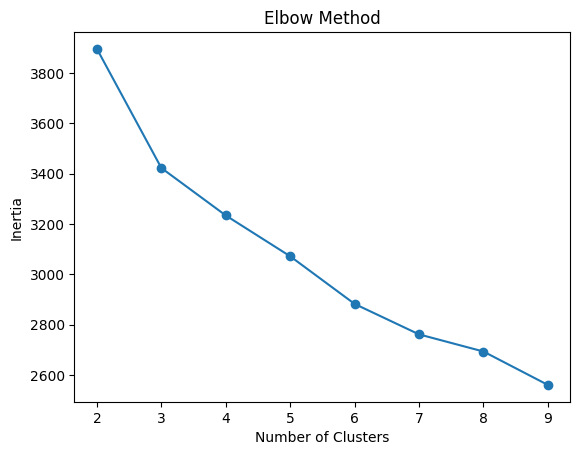

In [31]:
inertia = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [32]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)


In [33]:
hierarchical = AgglomerativeClustering(n_clusters=3)
df['Hierarchical_Cluster'] = hierarchical.fit_predict(X_scaled)


In [34]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)


In [35]:
numeric_profile = df.groupby('KMeans_Cluster').mean(numeric_only=True)
churn_rate = df.groupby('KMeans_Cluster')['Churn'].mean() * 100

segment_profile = numeric_profile.copy()
segment_profile['Churn_Rate_%'] = churn_rate

segment_profile


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn,Hierarchical_Cluster,DBSCAN_Cluster,Churn_Rate_%
KMeans_Cluster,,,,,,,,
0,37.452586,116.737069,4088.387931,0.469828,0.103448,0.025862,0.159483,10.344828
1,37.024194,107.282258,4216.282258,0.524194,0.153226,1.895161,1.459677,15.322581
2,34.625000,114.111111,4497.333333,0.520833,0.069444,0.937500,0.305556,6.944444


In [36]:
segment_sizes = df['KMeans_Cluster'].value_counts(normalize=True) * 100
segment_sizes


,proportion
KMeans_Cluster,
0,46.4
2,28.8
1,24.8


In [37]:
segment_names = {
    0: "Budget Conscious",
    1: "Premium Spenders",
    2: "Young Professionals"
}

df['Segment_Name'] = df['KMeans_Cluster'].map(segment_names)


In [38]:
# Keep a clean copy
df_model = df.copy()

# Drop non-predictive ID column if present
if 'CustomerID' in df_model.columns:
    df_model = df_model.drop(columns=['CustomerID'])

# Separate target
y = df_model['Churn']

# Drop target & clustering labels from features
X = df_model.drop(
    ['Churn', 'KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster', 'Segment_Name'],
    axis=1
)

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Store column names
feature_columns = X_encoded.columns


In [39]:
df_encoded = pd.concat(
    [df_model[['Churn', 'KMeans_Cluster']], X_encoded],
    axis=1
)


In [40]:
results = []

for segment in df_encoded['KMeans_Cluster'].unique():

    segment_data = df_encoded[df_encoded['KMeans_Cluster'] == segment]

    X_seg = segment_data.drop(['Churn', 'KMeans_Cluster'], axis=1)
    y_seg = segment_data['Churn']

    X_train, X_test, y_train, y_test = train_test_split(
        X_seg, y_seg, test_size=0.25, random_state=42, stratify=y_seg
    )

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Segment": segment_names[segment],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })


In [41]:
results_df = pd.DataFrame(results)
results_df


,Segment,Accuracy,Precision,Recall,F1,ROC_AUC
0,Premium Spenders,0.935484,0.800000,0.8,0.8,0.984615
1,Budget Conscious,1.000000,1.000000,1.0,1.0,1.000000
2,Young Professionals,0.916667,0.333333,0.5,0.4,0.941176


In [42]:
results_df = pd.DataFrame(results)
results_df


,Segment,Accuracy,Precision,Recall,F1,ROC_AUC
0,Premium Spenders,0.935484,0.800000,0.8,0.8,0.984615
1,Budget Conscious,1.000000,1.000000,1.0,1.0,1.000000
2,Young Professionals,0.916667,0.333333,0.5,0.4,0.941176


In [43]:
results_df.to_csv("model_evaluation_results.csv", index=False)


In [45]:
# df_encoded contains:
# Churn | KMeans_Cluster | encoded feature columns only
df_encoded.head()


,Churn,KMeans_Cluster,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Contract_One year,Contract_Two year,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,PaperlessBilling_Yes
0,0,1,6,64,1540,1,True,False,True,False,False
1,0,0,21,113,1753,1,False,False,False,True,True
2,0,2,27,31,1455,1,False,True,True,False,False
3,0,0,53,29,7150,1,False,False,False,True,False
4,0,0,16,185,1023,1,True,False,False,True,False


In [46]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

best_models = {}

for segment in df_encoded['KMeans_Cluster'].unique():

    segment_data = df_encoded[df_encoded['KMeans_Cluster'] == segment]

    X_seg = segment_data.drop(['Churn', 'KMeans_Cluster'], axis=1)
    y_seg = segment_data['Churn']

    X_train, X_test, y_train, y_test = train_test_split(
        X_seg, y_seg,
        test_size=0.25,
        random_state=42,
        stratify=y_seg
    )

    rf = RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    )

    grid = GridSearchCV(
        rf,
        param_grid,
        cv=3,
        scoring='f1',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[segment_names[segment]] = grid.best_params_


In [47]:
best_models


{'Premium Spenders': {'max_depth': None,
  'min_samples_split': 5,
  'n_estimators': 100},
 'Budget Conscious': {'max_depth': None,
  'min_samples_split': 5,
  'n_estimators': 100},
 'Young Professionals': {'max_depth': None,
  'min_samples_split': 5,
  'n_estimators': 200}}

In [48]:
business_recommendations = {
    "Premium Spenders": [
        "Offer loyalty programs",
        "Early access to premium features",
        "Personal account managers"
    ],
    "Budget Conscious": [
        "Discount offers",
        "Bundle pricing",
        "Price-sensitive promotions"
    ],
    "Young Professionals": [
        "Mobile-first experiences",
        "Subscription-based plans",
        "Referral incentives"
    ]
}

business_recommendations


{'Premium Spenders': ['Offer loyalty programs',
  'Early access to premium features',
  'Personal account managers'],
 'Budget Conscious': ['Discount offers',
  'Bundle pricing',
  'Price-sensitive promotions'],
 'Young Professionals': ['Mobile-first experiences',
  'Subscription-based plans',
  'Referral incentives']}

In [49]:
# Select important columns for submission
segmentation_data = df[
    ['KMeans_Cluster', 'Segment_Name', 'Churn']
]

# Save to CSV
segmentation_data.to_csv("segmentation_data.csv", index=False)

segmentation_data.head()


,KMeans_Cluster,Segment_Name,Churn
0,1,Premium Spenders,0
1,0,Budget Conscious,0
2,2,Young Professionals,0
3,0,Budget Conscious,0
4,0,Budget Conscious,0
